# Notebook 1: Data Exploration & Preprocessing

**Course:** M7016H — Artificial Intelligence within the Healthcare System
**Dataset:** Pima Indians Diabetes Dataset (Dataset 4)
**Authors:** Jamshaid Amjad, Shameena Mohammed Nabeel

---

This notebook covers everything from loading the raw CSV through to producing the
clean, scaled, feature-selected splits that the models in Notebook 2 will train on.
The idea is to understand the data properly before touching any model — it's easy
to skip this step and end up with a pipeline built on shaky foundations.

## 1. Setup

In [1]:
import sys
import os

# make sure we can import from src/
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.3f}".format)

## 2. Load the Raw Data

The dataset comes from the National Institute of Diabetes and Digestive and Kidney Diseases
(Smith et al., 1988). It contains clinical measurements for 768 Pima Native American women
aged 21 or older, each labelled as diabetic (1) or non-diabetic (0).

In [2]:
RAW_CSV = Path("../data/raw/diabetes.csv")
df = pd.read_csv(RAW_CSV)

print(f"Shape: {df.shape}")
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.600,0.627,50,1
1,1,85,66,29,0,26.600,0.351,31,0
2,8,183,64,0,0,23.300,0.672,32,1
3,1,89,66,23,94,28.100,0.167,21,0
4,0,137,40,35,168,43.100,2.288,33,1


In [3]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.000,3.845,3.370,0.000,1.000,3.000,6.000,17.000
Glucose,768.000,120.895,31.973,0.000,99.000,117.000,140.250,199.000
BloodPressure,768.000,69.105,19.356,0.000,62.000,72.000,80.000,122.000
SkinThickness,768.000,20.536,15.952,0.000,0.000,23.000,32.000,99.000
Insulin,768.000,79.799,115.244,0.000,0.000,30.500,127.250,846.000
BMI,768.000,31.993,7.884,0.000,27.300,32.000,36.600,67.100
DiabetesPedigreeFunction,768.000,0.472,0.331,0.078,0.244,0.372,0.626,2.420
Age,768.000,33.241,11.760,21.000,24.000,29.000,41.000,81.000
Outcome,768.000,0.349,0.477,0.000,0.000,0.000,1.000,1.000


A few things stand out straight away from the summary statistics:

- **Glucose**, **BMI**, **BloodPressure**, **SkinThickness**, and **Insulin** all have
  a minimum value of 0. Physiologically, a glucose concentration or BMI of zero is
  impossible — these zeros almost certainly encode missing values rather than true
  measurements (a known quirk of this dataset).
- **Insulin** has a very high standard deviation (115) relative to its mean (79),
  which is consistent with a lot of zero/missing values pulling the distribution around.

We'll deal with this in the preprocessing section. First, let's look at the class balance.

## 3. Class Distribution

Knowing whether the dataset is balanced is important — it affects which metrics
we should rely on and whether we need to do anything to correct the imbalance during training.

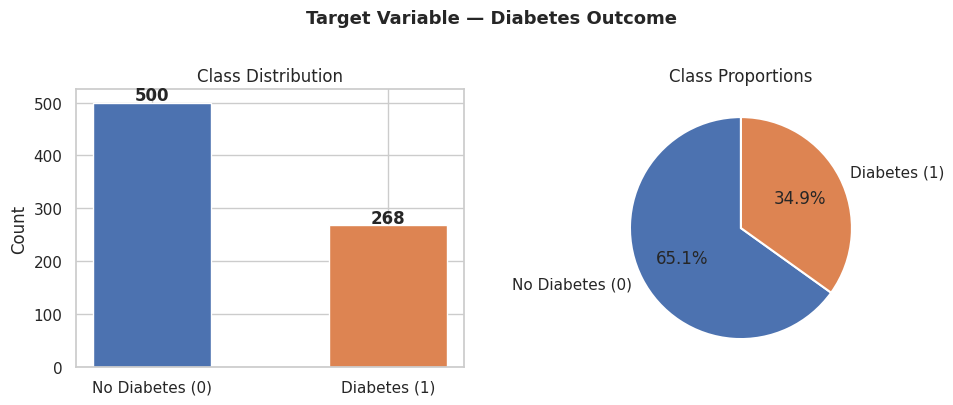

In [5]:
counts = df["Outcome"].value_counts()
labels = ["No Diabetes (0)", "Diabetes (1)"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(labels, counts.values, color=["#4C72B0", "#DD8452"], width=0.5, edgecolor="white")
axes[0].set_ylabel("Count")
axes[0].set_title("Class Distribution")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

# Pie chart
axes[1].pie(
    counts.values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4C72B0", "#DD8452"],
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
axes[1].set_title("Class Proportions")

plt.suptitle("Target Variable — Diabetes Outcome", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../outputs/figures/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

The dataset is moderately imbalanced — **34.9% positive** (diabetic) vs **65.1% negative**.
This is enough of a skew that a naive classifier that always predicts "no diabetes" would
achieve ~65% accuracy without learning anything useful. We'll address this with SMOTE
oversampling during preprocessing.

## 4. Missing Value Analysis

As noted above, zero values in several columns are physiologically meaningless.
Let's quantify how many there are per feature before we replace them.

               Zero Count  % of Rows
Glucose                 5      0.651
BloodPressure          35      4.557
SkinThickness         227     29.557
Insulin               374     48.698
BMI                    11      1.432


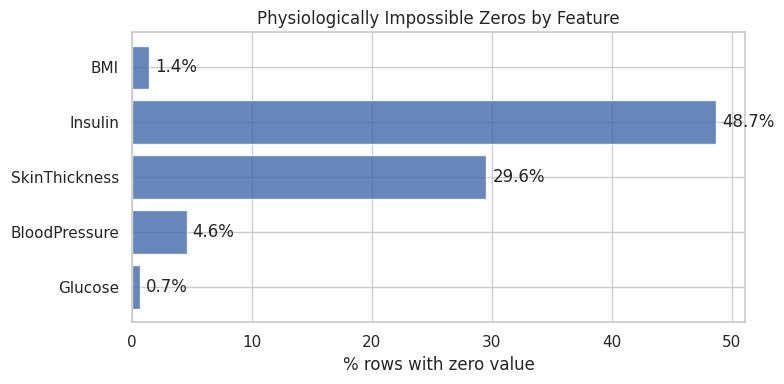

In [6]:
# These features cannot legitimately be zero
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_counts = {col: (df[col] == 0).sum() for col in zero_cols}
zero_pct    = {col: (df[col] == 0).mean() * 100 for col in zero_cols}

missing_df = pd.DataFrame({
    "Zero Count": zero_counts,
    "% of Rows": zero_pct,
})
print(missing_df.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(list(zero_counts.keys()), list(zero_pct.values()),
               color="#4C72B0", edgecolor="white", alpha=0.85)
for bar, pct in zip(bars, zero_pct.values()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}%", va="center")
ax.set_xlabel("% rows with zero value")
ax.set_title("Physiologically Impossible Zeros by Feature")
plt.tight_layout()
plt.savefig("../outputs/figures/missing_values.png", dpi=150, bbox_inches="tight")
plt.show()

**Insulin** is the worst offender — nearly half the rows have a recorded value of zero,
which is clearly not a real measurement. **SkinThickness** is also heavily affected at ~30%.
These will be replaced with `NaN` and later imputed with the training-set median.

## 5. Feature Distributions

Let's look at how each feature is distributed, split by diabetes outcome.
This gives an early sense of which features might be useful discriminators.

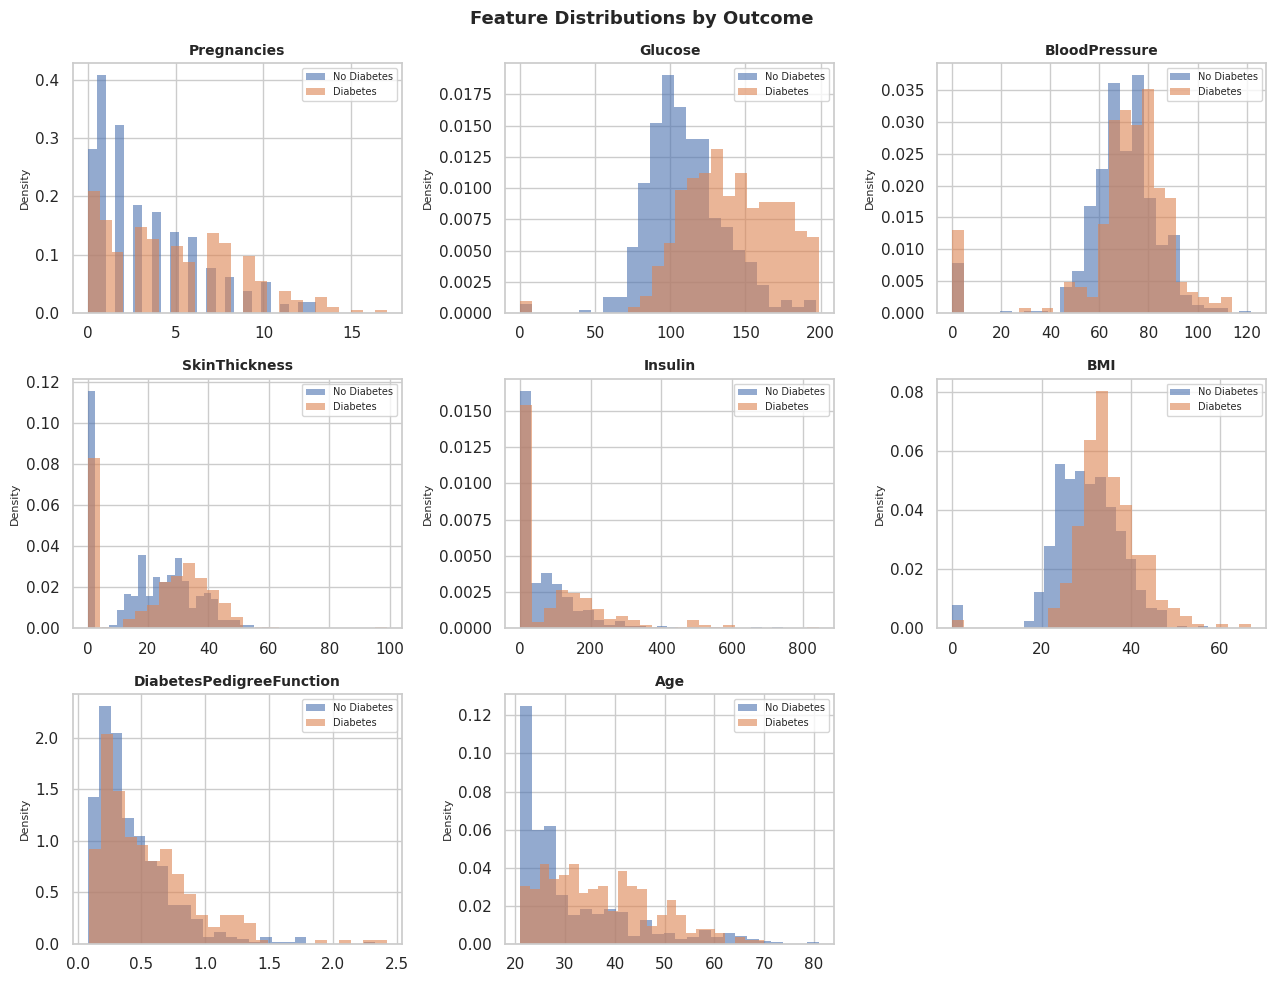

In [7]:
features = [c for c in df.columns if c != "Outcome"]

fig, axes = plt.subplots(3, 3, figsize=(13, 10))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    for outcome, color, label in [(0, "#4C72B0", "No Diabetes"), (1, "#DD8452", "Diabetes")]:
        vals = df.loc[df["Outcome"] == outcome, feat]
        ax.hist(vals, bins=25, alpha=0.6, color=color, label=label, edgecolor="none", density=True)
    ax.set_title(feat, fontsize=10, fontweight="bold")
    ax.set_ylabel("Density", fontsize=8)
    ax.legend(fontsize=7)

# hide the spare subplot
axes[-1].set_visible(False)

fig.suptitle("Feature Distributions by Outcome", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

**Glucose** shows the clearest separation between classes — diabetic patients tend to
have noticeably higher glucose concentrations. **BMI** and **Age** also show some
separation, though with more overlap. **BloodPressure** and **Pregnancies** are
harder to distinguish visually.

## 6. Correlation Analysis

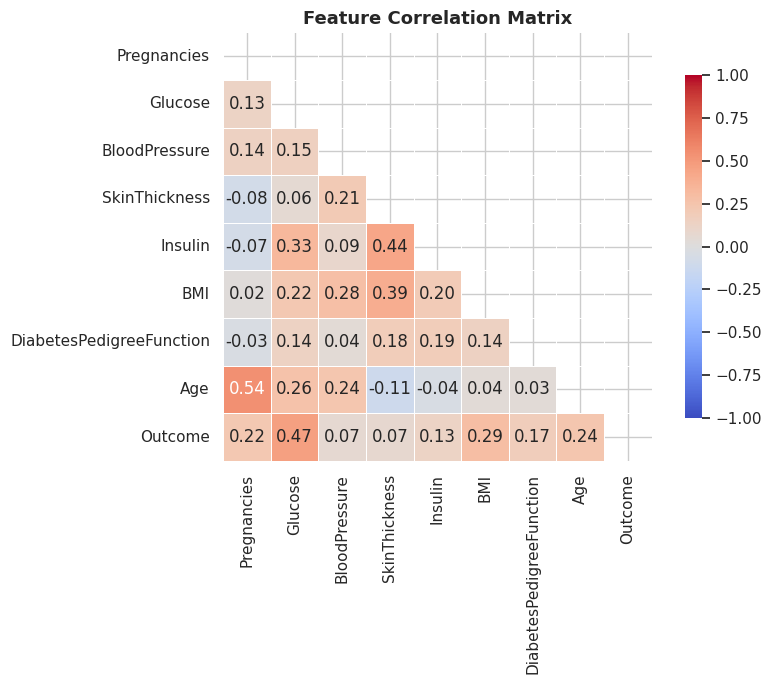

In [8]:
corr = df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, vmin=-1, vmax=1, ax=ax,
    square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
)
ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# Just the correlations with the target — sorted
target_corr = corr["Outcome"].drop("Outcome").sort_values(ascending=False)
print("Correlation with Outcome:")
print(target_corr.to_string())

Correlation with Outcome:
Glucose                    0.467
BMI                        0.293
Age                        0.238
Pregnancies                0.222
DiabetesPedigreeFunction   0.174
Insulin                    0.131
SkinThickness              0.075
BloodPressure              0.065


**Glucose** has by far the strongest correlation with the outcome (0.49), consistent
with its clinical role as the primary diagnostic marker for diabetes. **BMI** and **Age**
follow. Features like **BloodPressure** and **SkinThickness** have weaker correlations,
suggesting they may add less signal on their own — though interactions between features
can still make them useful in tree-based models.

## 7. Preprocessing Pipeline

Now that we understand the data, let's run the full preprocessing pipeline.
All steps are implemented in `src/data/dataset.py` and configured via `config/config.yaml`.

The steps, in order:
1. Replace physiologically impossible zeros with `NaN`
2. Stratified 70 / 15 / 15 train–validation–test split
3. Median imputation (fitted on training data only, to prevent leakage)
4. StandardScaler normalisation (again, fitted on training data only)
5. Feature selection — top-5 features by averaged ANOVA F-test and Random Forest importance ranks
6. SMOTE oversampling (training set only) to correct class imbalance

In [10]:
import yaml
from src.data.dataset import build_dataset

with open("../config/config.yaml") as f:
    cfg = yaml.safe_load(f)

csv_path = Path("../data/raw") / cfg["data"]["filename"]

data = build_dataset(
    csv_path=str(csv_path),
    val_split=cfg["data"]["val_split"],
    test_split=cfg["data"]["test_split"],
    n_features=cfg["data"]["n_features_to_select"],
    use_smote=cfg["data"]["use_smote"],
    random_seed=cfg["project"]["random_seed"],
    processed_dir="../data/processed",
)

print("Features selected:", data["selected_features"])
print()
print(f"Train set (after SMOTE) : {data['X_train'].shape}")
print(f"Validation set          : {data['X_val'].shape}")
print(f"Test set                : {data['X_test'].shape}")

Features selected: ['Glucose', 'BMI', 'Insulin', 'Age', 'Pregnancies']

Train set (after SMOTE) : (700, 5)
Validation set          : (115, 5)
Test set                : (116, 5)


### Why these five features?

Feature selection combines two complementary methods:
- **ANOVA F-test** (filter method) — measures the statistical association between each
  feature and the target independently of any model
- **Random Forest importance** (embedded method) — captures non-linear relationships
  and interactions that the F-test misses

Averaging their ranks makes the selection more robust than relying on either alone.
The five selected features — **Glucose, BMI, Insulin, Age, Pregnancies** — are consistent
with what the clinical literature identifies as primary risk factors for Type 2 diabetes.

In [11]:
# Quick sanity check on the processed splits
print("Class balance in training set after SMOTE:")
unique, counts = np.unique(data["y_train"], return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {int(u)}: {c} samples  ({c/len(data['y_train'])*100:.1f}%)")

print()
print("Class balance in test set (no SMOTE applied):")
unique, counts = np.unique(data["y_test"], return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {int(u)}: {c} samples  ({c/len(data['y_test'])*100:.1f}%)")

Class balance in training set after SMOTE:
  Class 0: 350 samples  (50.0%)
  Class 1: 350 samples  (50.0%)

Class balance in test set (no SMOTE applied):
  Class 0: 75 samples  (64.7%)
  Class 1: 41 samples  (35.3%)


SMOTE successfully balanced the training set to 50/50 while the test set retains
the original class distribution — this is important so that test metrics reflect
real-world performance rather than an artificially balanced evaluation.

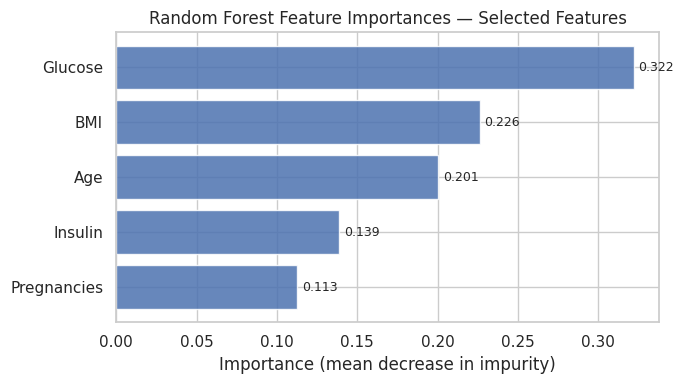

In [12]:
# Feature importance from feature selection step — visual
fig, ax = plt.subplots(figsize=(7, 4))
features_selected = data["selected_features"]

# We'll load the RF-based importance scores from the saved figure context
# by rerunning a quick RF on the training data for visualisation purposes
from sklearn.ensemble import RandomForestClassifier

rf_tmp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_tmp.fit(data["X_train"], data["y_train"])
importances = rf_tmp.feature_importances_
indices = np.argsort(importances)
sorted_features = [features_selected[i] for i in indices]

bars = ax.barh(sorted_features, importances[indices], color="#4C72B0",
               edgecolor="white", alpha=0.85)
for bar, val in zip(bars, importances[indices]):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9)
ax.set_xlabel("Importance (mean decrease in impurity)")
ax.set_title("Random Forest Feature Importances — Selected Features")
plt.tight_layout()
plt.savefig("../outputs/figures/feature_selection.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

| Step | Details |
|------|---------|
| Raw shape | 768 rows × 8 features + 1 target |
| Missing (zeros) | Glucose 5.2%, BloodPressure 4.6%, SkinThickness 29.6%, Insulin 48.7%, BMI 1.4% |
| Class imbalance | 65.1% / 34.9% (corrected with SMOTE in training only) |
| Train / Val / Test | 700 / 115 / 116 (after SMOTE: 700 balanced) |
| Selected features | Glucose, BMI, Insulin, Age, Pregnancies |

The data is now clean, scaled, and ready for model training. Head to **Notebook 2** to train all three models.